<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/12_langchain_mcp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastmcp langchain langchain-mcp-adapters langchain_google_genai -q uvicorn tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.5/213.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 17.3 MB/s eta 0:00:00


In [2]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
TAVILY_API_KEY = userdata.get("TAVILY_API_KEY")

In [3]:
from fastmcp import FastMCP
from tavily import TavilyClient

tavily = TavilyClient(api_key=TAVILY_API_KEY)

mcp = FastMCP("my-mcp")

@mcp.tool
def greet(msg: str):
    print("Incoming request")
    return f"Hello {msg}!"

@mcp.tool
def search_internet(query: str):
    '''This tool helps to search the given query across internet using tavily api'''
    print("Search_Internet tool invoked")
    return tavily.search(query)

In [4]:
import threading
import uvicorn

app = mcp.http_app()

def run_mcp_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

thread = threading.Thread(target=run_mcp_server, daemon=True)
thread.start()

print("MCP server started in a background thread on http://0.0.0.0:8000")

MCP server started in a background thread on http://0.0.0.0:8000


In [5]:
from langchain_mcp_adapters.client import MultiServerMCPClient

local_client = MultiServerMCPClient({
    "my-mcp": {
        "transport": "http",
        "url": "http://127.0.0.1:8000/mcp/"
    }
})

tools = await local_client.get_tools()
tools

INFO:     127.0.0.1:44930 - "POST /mcp/ HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:44930 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:44946 - "POST /mcp/ HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:44962 - "GET /mcp/ HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:44946 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:44962 - "GET /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:44972 - "POST /mcp/ HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:44972 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:44986 - "DELETE /mcp/ HTTP/1.1" 307 Temporary Redirect
INFO:     127.0.0.1:44986 - "DELETE /mcp HTTP/1.1" 200 OK


[StructuredTool(name='greet', args_schema={'additionalProperties': False, 'properties': {'msg': {'type': 'string'}}, 'required': ['msg'], 'type': 'object'}, metadata={'_meta': {'fastmcp': {'tags': []}}}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7ac5da8220c0>),
 StructuredTool(name='search_internet', description='This tool helps to search the given query across internet using tavily api', args_schema={'additionalProperties': False, 'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}, metadata={'_meta': {'fastmcp': {'tags': []}}}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x7ac5da8223e0>)]

In [9]:
from pprint import pprint
travel_client = MultiServerMCPClient(
    {
        "travel_server": {
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

travel_tools = await travel_client.get_tools()
pprint(travel_tools)

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

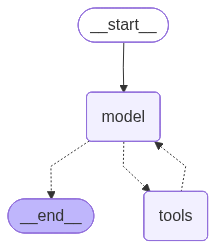

In [13]:
from langchain.agents import create_agent
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview",api_key=GOOGLE_API_KEY)
search_agent = create_agent(model=model, tools=tools + travel_tools)

search_agent

In [ ]:
from pprint import pprint

response = await search_agent.ainvoke({"messages":["State elections in India in April 2026"]})
pprint(response)

In [ ]:
response = await search_agent.ainvoke({"messages": ["Give me the flight price between Chennai and Lisbon for 2nd June 2026"]})
pprint(response)

In [22]:
print(response['messages'][-1].content[-1]['text'])

Here are the available flights from Chennai (MAA) to Lisbon (LIS) on 2nd June 2026:

| Route | Departure → Arrival & Duration | Cabin | Price | Book |
| :--- | :--- | :--- | :--- | :--- |
| Chennai → New Delhi → Milan → Lisbon | 02/06 06:55 → 23:20 (20h 55m) | Economy | €434 | [Book](https://on.kiwi.com/x7TjAD) |
| Chennai → Bengaluru → Abu Dhabi → Lisbon | 02/06 05:50 → 07:30 (30h 10m) | Economy | €499 | [Book](https://on.kiwi.com/B8voJE) |
| Chennai → Bengaluru → Manama → Milan → Lisbon | 02/06 19:05 → 13:15 (22h 40m) | Economy | €522 | [Book](https://on.kiwi.com/Jo6toZ) |
| Chennai → Bengaluru → Abu Dhabi → Lisbon | 02/06 10:45 → 07:30 (25h 15m) | Economy | €533 | [Book](https://on.kiwi.com/I77ZfQ) |
| Chennai → Bengaluru → Abu Dhabi → Lisbon | 02/06 10:55 → 07:30 (25h 05m) | Economy | €540 | [Book](https://on.kiwi.com/gHugIU) |
| Chennai → Abu Dhabi → Lisbon | 02/06 10:15 → 07:30 (25h 45m) | Economy | €555 | [Book](https://on.kiwi.com/nlQMXl) |
| Chennai → Mumbai → Abu Dhabi → Lisb